# 12. (Bonus) Agentic Reinforcement Learning

> ⚡Compute Note: I recommend running this notebook on a node with 1x H200 GPU. 

Now that you've seen the basic of *agentic AI* (multi-turn agents, tool calls, planning, memory) and you’ve built agents with **Pydantic AI**, you’ve likely run into the next question: “Cool — my agent can use tools. But how do I make it **better** at using them over time, without hand-labeling thousands of examples?”.

One of the most powerful answers is **co-evolution**. Co-evolution means you don’t just train a single agent in isolation — you train *a small ecosystem of agents* that push each other forward. In our setting, that ecosystem has three roles: a **Problem Creator** that invents tasks, a **Solver** that attempts to solve them (using tools like web search over multiple turns), and a **Judge** that evaluates the Solver’s output. As the Solver gets stronger, the same old easy problems stop teaching it anything new. Co-evolution solves this by letting the Problem Creator adapt too: it learns to generate harder (but still valid) problems that expose the Solver’s weaknesses. This creates an automatic **curriculum** that evolves with the agent, rather than staying static. This idea originates from the self-play that led to the revolutionary AI of [AlphaZero](https://www.youtube.com/watch?v=7L2sUGcOgh0). The world's a messy place, humans haven't cracked many aspects of it, which AI can with more compute. To develop super-intelligent AI, that's more powerful than any human, I strongly feel co-evolution is the way to go.

To make this more concrete, imagine training only a Solver on a fixed set of questions. At first it improves quickly, then it plateaus because it has effectively “overfit” the difficulty level of the training distribution. With co-evolution, the distribution itself keeps shifting: the Problem Creator explores new edge cases, the Solver learns to handle them, and the Judge enforces what “good” looks like. Over many rounds, you get a dynamic, self-generated training signal that can keep producing learning pressure even when you started with **no labeled dataset**.

This is where **reinforcement learning (RL) fine-tuning** comes in. Instead of teaching the model to imitate a target answer (“here is the correct response, learn to copy it”), RL fine-tuning teaches it to optimize a **reward**: the model produces an output, receives a score that reflects quality, and training nudges the model toward actions (tokens, tool calls, reasoning patterns) that earn higher rewards in the future. In agentic settings, this is especially appealing because we care about behaviors that aren’t easy to label upfront: when to search, what to search, how to combine evidence, how to structure the final response, and how to stay consistent across multiple turns.

But where do rewards come from if we don’t have labeled data? A practical and widely used trick is **LLM-as-a-Judge**. Here, another language model plays the role of evaluator: given the question, the solver’s answer (and optionally a rubric or reference answer), it outputs a numeric score and short feedback. This turns qualitative judgment into a scalar signal that RL can optimize. It’s not perfect — judges can be inconsistent or biased — but it’s an extremely useful bootstrapping mechanism, and we’ll include sanity checks and guardrails so the signal stays meaningful.

> *"The only way to get smarter is to play a smarter opponent."*


### 🎯 What We're Building

In this chapter, we create something fascinating: **two AI agents that make each other smarter** through adversarial co-training. Think of it like a chess player who improves by playing against increasingly skilled opponents — except here, both players are learning simultaneously!

| Agent | Role | Goal |
|-------|------|------|
| 🧩 **Problem Creator** | Medical educator | Generate challenging clinical cases |
| 🔍 **Solver** | Medical expert | Diagnose cases using web search |
| ⚖️ **Judge** | External evaluator | Score solutions for accuracy & safety |


Let's build something that learns to challenge itself! 🚀

First, let's import our core libraries and verify GPU availability.

In [4]:
import os
import re
import torch
import numpy as np
from dataclasses import dataclass, field
from typing import List, Dict
from dotenv import load_dotenv

from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import LoraConfig, get_peft_model

torch.manual_seed(42) 
load_dotenv()

# Check GPU
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

CUDA available: True
GPU: NVIDIA H200


## 🧬 Load Model with Multi-Adapter LoRA

To make model tuning practical, we use **[LoRA](https://huggingface.co/docs/diffusers/en/training/lora)** (parameter-efficient fine-tuning). Instead of updating the full Qwen3 model weights, we’ll attach small trainable adapter matrices and keep the base model mostly frozen. This keeps training lightweight and fast, and it also makes it easy to maintain multiple *roles* (Problem Creator, Solver, Judge) as separate adapters — all built on top of the same base model. In other words, we’ll start with one foundation model, “split” it into three roles via prompts and LoRA adapters, and then let those roles co-evolve through self-play.

In the rest of this notebook, we’ll build this system end-to-end: first the multi-turn tool-using agent loop, then the judge-based reward function, then GRPO training of the Solver, and finally the co-evolution loop where the Problem Creator adapts adversarially to keep the Solver learning.

We’ll start from a single **base** Qwen3 model and add **LoRA adapters** on top. Think of the base model as the shared “brain,” and each adapter as a lightweight specialization layer that we can train independently for different roles.

In this notebook we’ll maintain multiple roles:
- **Problem** adapter: generates medical questions/cases.
- **Solver** adapter: solves questions using multi-turn reasoning + web search.
- *(Later)* **Judge** adapter: scores the solver’s outputs to produce rewards.

Why this design?
- **Parameter-efficient**: LoRA trains a tiny fraction of parameters, making RL fine-tuning feasible on a single GPU.
- **Shared foundation, separate behaviors**: all agents inherit the same general language ability from Qwen3, but adapters let them diverge into different “personalities” and objectives.
- **Easy switching**: we can swap `problem` ↔ `solver` adapters inside the same model instance instead of loading three full models.

A couple of small details you’ll see in the cell below:
- We set `pad_token = eos_token` (common for causal LMs).
- We set `padding_side = "left"` so generation works nicely with batched prompts.
- We target Qwen’s projection layers (q/k/v/o and MLP projections) for LoRA, which is a good default for instruction-tuned transformer LMs.

### 🔧 Why Multi-Adapter?

Instead of training two separate models (expensive!), we share the same base weights and only train lightweight adapters:

**Result:** ~1% trainable parameters, 2 independent agents!

In [5]:
# Load tokenizer and model
MODEL_ID = "Qwen/Qwen3-1.7B"

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

print(f"Loading {MODEL_ID}...")
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)

# Create LoRA config and PEFT model
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    task_type="CAUSAL_LM",
)

peft_model = get_peft_model(base_model, lora_config)

# Add separate adapters for each agent
peft_model.add_adapter("problem", lora_config)
peft_model.add_adapter("solver", lora_config)

def set_adapter(name: str):
    peft_model.set_adapter(name)

peft_model.print_trainable_parameters()

`torch_dtype` is deprecated! Use `dtype` instead!


Loading Qwen/Qwen3-1.7B...


Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


trainable params: 17,432,576 || all params: 2,084,037,632 || trainable%: 0.8365


## 🔍 Web Search Tool

Our agents going to be *tool-using* and *multi-turn*. In practice, that means it should be able to:
1) decide **when** it needs external information,  
2) issue a search query,  
3) read the results, and  
4) continue reasoning in subsequent turns.

To keep things hands-on and realistic, we’ll wire up a simple web-search tool using **[Tavily](https://tavily.com/)** (a search API commonly used for agent demos). This gives us fast, LLM-friendly snippets rather than raw HTML.

Two important implementation choices in the cell below:

**Caching**
- During RL training we may call search many times on similar queries.
- A cache prevents repeated identical requests, making rollouts cheaper and faster.
- It also reduces variance in training (same query → same snippet).

**Returning compact evidence**
- We return short, text-only snippets (title + truncated content).
- This keeps tool outputs small enough to fit into the model context window while still being informative.

> **Setup requirement:** Make sure you have `TAVILY_API_KEY` set in your `.env` file.  

In the next cell, we implement `web_search()` and run a quick test query.

### 🛡️ Why Tool Use in RL?

Traditional RL trains models on their internal knowledge only. By adding tool use:

1. **Grounded outputs** — Answers backed by real sources
2. **Up-to-date knowledge** — Access to current medical guidelines
3. **Reduced hallucination** — Can verify facts before answering

In [3]:
from tavily import TavilyClient

tavily_client = TavilyClient(api_key=os.getenv("TAVILY_API_KEY"))
search_cache = {}

def web_search(query: str, max_results: int = 3) -> str:
    """
    Search the web for medical information.

    Args:
        query: The search query to execute.
        max_results: Maximum number of results to return.

    Returns:
        Formatted search results as a string containing titles and content snippets.
    """
    if query in search_cache:
        return search_cache[query]
    
    try:
        response = tavily_client.search(query, max_results=max_results)
        results = []
        for r in response.get('results', []):
            results.append(f"{r.get('title', '')}\n{r.get('content', '')[:300]}")
        result = "\n\n".join(results) if results else "No results found."
    except Exception as e:
        result = f"Search failed: {e}"
    
    search_cache[query] = result
    return result

# Test
print(web_search("diabetic ketoacidosis treatment", max_results=1)[:200] + "...")

Diabetic Ketoacidosis - CDC
Your treatment will likely include: Replacing fluids you lost through frequent urination and to help dilute excess sugar in your blood....


## 🎭 Agent System with Curriculum

Before we can do RL and co-evolution, we need a clean **interaction protocol** for our agents. Think of this as defining the “environment” the models will play in:

- The **Problem agent** must output a clinical case in a consistent structure.
- The **Solver agent** must respond in a consistent structure so a Judge can score it later.
- We also want control over **difficulty**, because learning works best when tasks are neither too easy nor impossible.

### Why a difficulty curriculum?
Early on, the Solver will be weak. If we immediately throw “expert” cases at it, rewards will be near zero and learning becomes noisy. A curriculum lets us:
- start with easy cases (high signal),
- gradually increase difficulty as performance improves,
- and later transition into **coevolution**, where the Problem agent itself learns what “hard” means for the current Solver.

In this section we’ll implement a simple **5-level difficulty scale**. For now, difficulty is driven by prompts (“Basic” → “Expert”), which is the simplest form of curriculum learning. Later, we’ll replace or augment this with an adversarial reward so the Problem agent *learns* to generate appropriately challenging tasks.

### Why strict output formats?
When multiple agents interact, structure matters. We enforce `FINAL_ANSWER:` blocks so downstream components can reliably:
- extract the case text,
- extract the solution,
- and eventually compute rewards without fragile parsing.

### Efficient generation: batched sampling + adapter switching
To keep training loops fast, we generate multiple problems/solutions in a single forward pass (batching). We also switch between LoRA adapters (`problem` vs `solver`) inside the same model instance. This is a practical trick: one base model, multiple role behaviors.

In the next cell, we:
1) define difficulty prompts,  
2) define system prompts for the Problem and Solver roles, and  
3) implement `generate_problems()` and `solve_problems()` using batched generation.

In [4]:
import re, json

# Difficulty prompts for curriculum learning
DIFFICULTY_PROMPTS = {
    1: "Create a BASIC medical case with one clear symptom and obvious diagnosis.",
    2: "Create a STRAIGHTFORWARD case with 2-3 symptoms and typical presentation.",
    3: "Create a MODERATE case requiring differential diagnosis between 2-3 conditions.",
    4: "Create a CHALLENGING case with multiple organ systems involved.",
    5: "Create an EXPERT case with rare conditions or atypical presentations.",
}

PROBLEM_PROMPT = """You are a medical educator. Generate ONE clinical case problem. Be very brief in thinking. 

You have access to web search to find realistic clinical details. Use it at least once and at max twice before providing your final answer.

Rules:
1. Think about what case to create
2. Include patient demographics, symptoms, and relevant findings
3. Use web_search for realistic clinical details to make the case authentic
4. Provide your answer in this format:

FINAL_ANSWER: [case description]"""


SOLVER_PROMPT = """You are a medical expert. Solve this case with reasoning.

You have access to web_search tool to verify medical information. Use it at least once and at max twice before providing your final answer.

Rules:
1. Analyze the case systematically
2. Search for relevant medical guidelines or diagnostic criteria
3. Provide your answer in this format:

FINAL_ANSWER:
Key findings: [list]
Diagnosis: [answer]
Reasoning: [explanation]"""

device = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 8
MAX_TOKENS = 512

def extract_tool_calls(text: str) -> List[dict]:
    """Extract tool calls from Qwen3's <tool_call> JSON format."""
    pattern = r'<tool_call>\s*(\{.*?\})\s*</tool_call>'
    matches = re.findall(pattern, text, re.DOTALL)
    tool_calls = []
    for match in matches:
        try:
            tool_call = json.loads(match)
            tool_calls.append(tool_call)
        except json.JSONDecodeError:
            continue
    return tool_calls

def generate_batch(adapter_name: str, prompts: List[str], system_prompt: str,
                   max_tool_turns: int = 2) -> List[str]:
    """Batched GPU generation WITH native tool use support."""
    set_adapter(adapter_name)

    n = len(prompts)
    messages_list = [[{"role": "system", "content": system_prompt},
                      {"role": "user", "content": p}] for p in prompts]
    results = [""] * n
    active = list(range(n))

    for turn in range(max_tool_turns + 1):
        if not active:
            break

        # Use tokenizer with tools parameter for native function calling
        batch_texts = []
        for i in active:
            text = tokenizer.apply_chat_template(
                messages_list[i],
                tokenize=False,
                add_generation_prompt=True,
                tools=[web_search]  # Native tool format
            )
            batch_texts.append(text)

        inputs = tokenizer(batch_texts, return_tensors="pt", padding=True,
                          truncation=True, max_length=2048).to(device)

        with torch.no_grad():
            outputs = peft_model.generate(
                **inputs, max_new_tokens=2048, do_sample=True,
                temperature=0.7, pad_token_id=tokenizer.pad_token_id
            )

        # Decode and check for tool calls
        generated_texts = []
        for j, output in enumerate(outputs):
            input_len = inputs.input_ids[j].ne(tokenizer.pad_token_id).sum().item()
            gen = tokenizer.decode(output[input_len:], skip_special_tokens=True).strip()
            generated_texts.append(gen)
        
        # Process tool calls using Qwen3's <tool_call> JSON format
        next_active = []
        tool_queries = []
        tool_indices = []

        for j, i in enumerate(active):
            generated = generated_texts[j]
            tool_calls = extract_tool_calls(generated)

            if tool_calls and turn < max_tool_turns:
                # Get first tool call
                tool_call = tool_calls[0]
                if tool_call.get("name") == "web_search":
                    args = tool_call.get("arguments", {})
                    query = args.get("query", "")
                    max_results = args.get("max_results", 3)
                    if query:
                        tool_queries.append((query, max_results))
                        tool_indices.append((i, generated))
                        next_active.append(i)
            else:
                results[i] = generated

        # Execute tools in parallel
        if tool_queries:
            from concurrent.futures import ThreadPoolExecutor
            with ThreadPoolExecutor(max_workers=8) as executor:
                tool_results = list(executor.map(
                    lambda args: web_search(args[0], args[1]), tool_queries
                ))

            # Update messages with tool results
            for (i, generated), tool_result in zip(tool_indices, tool_results):
                results[i] += generated + "\n"
                messages_list[i].append({"role": "assistant", "content": generated})
                messages_list[i].append({"role": "tool", "content": tool_result})

        active = next_active

    # Extract FINAL_ANSWER
    final_results = []
    for r in results:
        if "FINAL_ANSWER:" in r:
            r = r[r.rindex("FINAL_ANSWER:"):].split("FINAL_ANSWER:", 1)[1].strip()
        final_results.append(r)

    return final_results

def generate_problems(difficulty: int, num: int) -> List[str]:
    """Generate medical problems at given difficulty."""
    prompts = [DIFFICULTY_PROMPTS[difficulty]] * num
    return generate_batch("problem", prompts, PROBLEM_PROMPT)

def solve_problems(problems: List[str]) -> List[str]:
    """Solve medical problems."""
    prompts = [f"Solve this case:\n\n{p}" for p in problems]
    return generate_batch("solver", prompts, SOLVER_PROMPT)

# Test the agents
print("Generating 2 problems at difficulty 2...")
problems = generate_problems(difficulty=2, num=2)
print(f"\nProblem 1:\n{problems[0]}...\nSearches made: {len(search_cache)}\nLast search: {list(search_cache.items())[-1]}")

print("\nSolving problems...")
solutions = solve_problems(problems)
print(f"\nSolution 1:\n{solutions[0]}...\nSearches made: {len(search_cache)}\nLast search: {list(search_cache.items())[-1]}")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Generating 2 problems at difficulty 2...



Problem 1:
A 55-year-old male with a history of hypertension and diabetes presents with sudden onset of chest pain (pressure in left chest), shortness of breath, and palpitations. Physical exam reveals tachycardia (110 bpm), elevated jugular venous pressure (JVP), and diminished breath sounds in the left lower lobe. Echocardiogram shows mild left ventricular dysfunction. Blood pressure is 160/95 mmHg, and BNP levels are 85 pg/mL (normal <100 pg/mL). The patient is suspected of having an acute myocardial infarction, and immediate evaluation for percutaneous coronary intervention (PCI) is initiated....
Searches made: 3
Last search: ('diabetic neuropathy symptoms and findings in elderly patients', 'Diabetic Neuropathy in Older Adults: Pathophysiological and ...\nOne of the most common and disabling of these in the elderly population is peripheral diabetic neuropathy (PDN), affecting more than 50% of individuals aged 60 to 80 years with T2DM [2]. In Latin America, approximately 32 million


Solution 1:
Key findings:  
- Sudden chest pain (left chest, pressure)  
- Shortness of breath  
- Palpitations  
- Tachycardia (110 bpm)  
- Elevated JVP  
- Diminished breath sounds in left lower lobe  
- Mild left ventricular dysfunction  
- BP 160/95 mmHg  
- BNP 85 pg/mL (borderline, <100 pg/mL)  

Diagnosis: Acute Myocardial Infarction (AMI) with Left Ventricular Dysfunction and Heart Failure  

Reasoning:  
1. **Clinical Correlation**: The patient’s symptoms (chest pain, shortness of breath, palpitations) and risk factors (hypertension, diabetes) are classic for AMI. The ECHO showing left ventricular dysfunction and BNP of 85 pg/mL (borderline) support this diagnosis.  
2. **BNP Interpretation**: While BNP is slightly elevated (85 pg/mL), it falls within the range seen in AMI (median 224 pg/mL in AMI vs. 56 pg/mL in other conditions). However, the presence of left ventricular dysfunction and clinical urgency suggest AMI.  
3. **Echocardiographic Findings**: Mild left ventricula

## ⚖️ LLM-as-Judge

Now we introduce the component that makes **RL without labeled data** possible: an **LLM-as-a-Judge**.

Instead of requiring a dataset of “correct answers,” we’ll ask a separate model to *grade* the Solver’s output and return a **numeric reward**. That reward becomes the learning signal for RL fine-tuning later (e.g., RL will try to push the Solver toward higher-scoring generations).

### Why use a judge model at all?
In agentic tasks, “good” is often hard to specify with simple rules:
- Was the diagnosis medically plausible?
- Did the reasoning use the right evidence?
- Did the response avoid unsafe advice?
- Did the agent hallucinate or overclaim?

A judge model can evaluate these dimensions in a more nuanced way than brittle heuristics.

### Why comparative scoring?
A key insight is that RL allows the model to learn from relative preferences, not absolute scores. Traditional independent scoring has problems:
- Calibration drift between API calls
- Inconsistent standards across evaluations
- Absolute scores are harder for LLMs than comparisons

By evaluating all solutions in a batch together, the judge can:
- Rank solutions relative to each other
- Provide internally consistent scores
- Better align with how humans naturally evaluate ("A is better than B")

### Why structured output?
We’re not just asking for a vague “good/bad” judgment. We want a **reliable schema**:
- `score` (overall reward in `[0, 1]`)
- `medical_accuracy`
- `reasoning_quality`
- `safety` (important for medical domain)
- `feedback` (human-readable critique, useful for debugging)

Using **Pydantic AI**, we can enforce this structure automatically and reduce parsing headaches. This also makes it easy to log metrics, plot trends, and later define reward functions like:
- `reward = score`
- or `reward = score * safety` (to strongly penalize unsafe outputs)

In the next cell, we define a `JudgeResponse` schema, create a `judge_agent`, and implement `evaluate_solution()` to return a structured reward and critique.

> 💡 **Design Choice**: We use an external model (Claude) as judge to avoid the "grading your own homework" problem.

In [5]:
import nest_asyncio
nest_asyncio.apply() 

from dataclasses import dataclass
from pydantic import BaseModel, Field
from pydantic_ai import Agent, RunContext, ModelRetry

@dataclass
class JudgeDeps:
    expected_count: int

class JudgeResponse(BaseModel):
    feedback: str
    score: float = Field(ge=0.0, le=1.0, description="Overall score")
    medical_accuracy: float = Field(ge=0.0, le=1.0)
    reasoning_quality: float = Field(ge=0.0, le=1.0)
    safety: float = Field(ge=0.0, le=1.0, description="1=safe, 0=dangerous")

class BatchJudgeResponse(BaseModel):
    evaluations: List[JudgeResponse] = Field(description="List of evaluations for each problem-solution pair, in order")

judge_agent = Agent(
    model="openrouter:anthropic/claude-sonnet-4.5",
    system_prompt="""Evaluate medical solutions on accuracy, reasoning, and safety. 
            Evaluate deeply, be strict but fair. Always use web-search to be sure.
            
            For each solution provide:
            - score: Overall quality (0-1, relative to others)
            - medical_accuracy: Correctness (0-1, relative)
            - reasoning_quality: Logic and evidence (0-1, relative)
            - safety: Is advice safe? (0-1, ABSOLUTE - dangerous = 0 always)
            - feedback: Brief explanation""",
    output_type=BatchJudgeResponse,
    deps_type=JudgeDeps,
    retries=3,
    model_settings={'seed': 42}
)

@judge_agent.tool
def web_search_tool(ctx: RunContext, query: str, max_results: int = 3) -> str:
    """Web search tool for judge."""
    return web_search(query, max_results)

@judge_agent.output_validator
async def validate_eval_count(ctx: RunContext[JudgeDeps], result: BatchJudgeResponse) -> BatchJudgeResponse:
    """Validate the number of evaluations matches expected count."""
    expected = ctx.deps.expected_count
    actual = len(result.evaluations)
    if actual != expected:
        raise ModelRetry(f"Expected {expected} evaluations but got {actual}.")
    return result

async def evaluate_solution(problem: str, solution: str) -> JudgeResponse:
    """Evaluate a solution using the LLM judge."""
    try:
        result = await judge_agent.run(f"Problem 1:\n{problem}\n\nSolution 1:\n{solution}\n\nEvaluate.", deps=JudgeDeps(expected_count=1))
        return result.output.evaluations[0]
    except Exception as e:
        print(f"Judge error: {e}")
        return JudgeResponse(score=0.3, medical_accuracy=0.3, reasoning_quality=0.3, safety=0.5, feedback=str(e))

# Test
print("Testing judge...")
judge_result = await evaluate_solution(problems[0], solutions[0])
print(f"Score: {judge_result.score:.2f}, Safety: {judge_result.safety:.2f}")
print(f"Feedback: {judge_result.feedback[:100]}...")

Testing judge...


Score: 0.35, Safety: 0.60
Feedback: MAJOR CONCERNS: The solution confirms an AMI diagnosis and proceeds to PCI without mentioning the mo...


## 🎯 Reward Functions

We now have a Judge that returns structured evaluation signals. The next step is to convert those signals into **numeric rewards** that we can optimize with RL.

This is a crucial design moment: the reward function is effectively the “rules of the game.” A small change here can drastically change what the agents learn.

### Solver reward: optimize quality, but punish unsafe behavior
For the **Solver**, we want high-quality medical reasoning — but we also want strong safety behavior. In medical tasks, an otherwise “correct” answer that gives unsafe advice is not acceptable.

So our solver reward is:
- a weighted combination of:
  - overall score,
  - medical accuracy,
  - reasoning quality,
- multiplied by a **safety penalty** if the Judge flags the output as unsafe.

This makes safety a *hard constraint* rather than an optional improvement.

### Problem reward: “hard but solvable” (the co-evolution sweet spot)
For the **Problem Creator**, we don’t want it to generate:
- impossibly hard cases (Solver always fails → no learning),
- or trivial cases (Solver always succeeds → no learning).

Instead, we reward problems that land in a **sweet spot** where the Solver’s score is around **0.5**. That means:
- the Solver is challenged,
- the Judge can still distinguish good vs bad solutions,
- and training signal remains informative.

We implement this as a simple “bell-shaped” curve peaking at 0.5 (and clamping extreme failure/success). We also optionally scale reward slightly by the declared difficulty level so the generator doesn’t collapse to only easy problems.

### Sanity check: visualize reward shapes
Before running any RL, it’s worth plotting reward curves. This helps you confirm:
- unsafe answers get meaningfully penalized,
- problem reward does what you intended (peak at mid-solver performance),
- and difficulty scaling isn’t overpowering.

In the next cell, we define `solver_reward()` and `problem_reward()` and plot how they behave across solver scores.


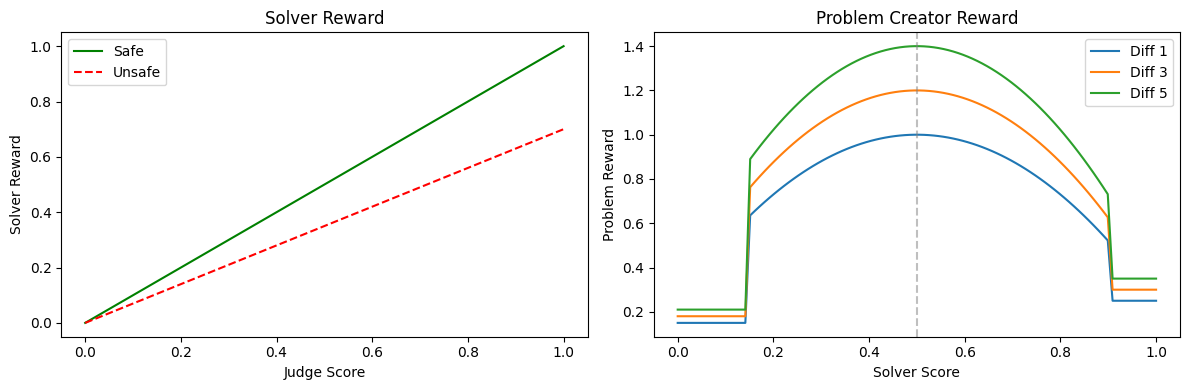

In [6]:
def solver_reward(judge: JudgeResponse) -> float:
    """Reward for solver - penalizes unsafe advice heavily."""
    safety_mult = 1.0 if judge.safety > 0.5 else 0.7
    return (0.4 * judge.score + 0.3 * judge.medical_accuracy + 0.3 * judge.reasoning_quality) * safety_mult

def problem_reward(solver_score: float, difficulty: int) -> float:
    """Reward for problem creator - sweet spot curve peaking at solver_score=0.5."""
    if solver_score < 0.15:
        challenge = 0.15  # Too hard
    elif solver_score > 0.9:
        challenge = 0.25  # Too easy
    else:
        challenge = 1.0 - 3 * (solver_score - 0.5) ** 2  # Peak at 0.5
    return challenge * (1.0 + (difficulty - 1) * 0.1)

# Visualize
import matplotlib.pyplot as plt
scores = np.linspace(0, 1, 100)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(scores, scores, 'g-', label='Safe'); ax1.plot(scores, scores * 0.7, 'r--', label='Unsafe')
ax1.set_xlabel('Judge Score'); ax1.set_ylabel('Solver Reward'); ax1.legend(); ax1.set_title('Solver Reward')

for d in [1, 3, 5]:
    ax2.plot(scores, [problem_reward(s, d) for s in scores], label=f'Diff {d}')
ax2.axvline(0.5, color='gray', linestyle='--', alpha=0.5)
ax2.set_xlabel('Solver Score'); ax2.set_ylabel('Problem Reward'); ax2.legend(); ax2.set_title('Problem Creator Reward')
plt.tight_layout(); plt.show()

## 📈 GRPO Training

To run RL fine-tuning efficiently in the HuggingFace ecosystem, we’ll use **[TRL](https://huggingface.co/docs/trl/en/index)** (Transformer Reinforcement Learning). TRL is essentially the “training engine” that handles the repetitive mechanics: sampling multiple answers from the policy, scoring them, computing learning signals, and applying updates. It saves you from implementing RL algorithms from scratch, while still letting you customize how rollouts happen (multi-turn tool use) and how rewards are computed (LLM-as-a-judge).

Within TRL, we’ll use an algorithm called **GRPO**. Intuitively, GRPO works by generating **multiple candidate answers per prompt**, scoring each one, and then pushing the model to prefer the higher-scoring generations *relative to* the lower-scoring ones. You can think of it as: “try K attempts, see which attempts the Judge likes more, and train the model so it becomes more likely to produce those attempts next time.” This makes GRPO especially natural for language models, because sampling diverse completions is easy, and relative preference learning tends to be more stable than relying on a single noisy score.

There have recently been proposed other advanced RL techniques such as Hop-Grouped Relative Polucy Optimization (HRPO) by [Meta](https://arxiv.org/pdf/2601.07055) that clusters structurally similar questions to minimize sampling overhead in evaluating each query; however, implementing HRPO is out of the scope of this tutorial.

### What GRPO will do for us (intuition, no math)
For each prompt, GRPO will:
1) sample **multiple completions** from the current policy (e.g., 4 attempts),
2) score each completion using our reward function,
3) update the model so higher-reward completions become **more likely** in the future.

This is a great fit for language models because “try a few answers and pick the best” is natural, and learning from *relative* quality can be more stable than relying on a single noisy score.

### Why we implement reward functions as Python callbacks
TRL expects a reward function that takes in the model’s generated **completions** and returns a list of floats.

That’s exactly what we can provide:
- `solver_reward_fn(...)`: uses the Judge to score solver answers and returns **solver rewards**.
- `problem_reward_fn(...)`: treats the generated text as a *problem*, runs the Solver on it, asks the Judge to score the solution, then returns a **problem reward** based on “hard-but-solvable.”

This is the key bridge between “agentic self-play” and “RL training.”

### Two important practical details
**1) Keeping track of which completion belongs to which problem**  
GRPO runs in batches. When training the Solver, we need to evaluate each completion against its corresponding problem statement. We maintain a small bit of state (`current_problems`) so the reward function can align completions with prompts.

**2) Training adapters, not the full model**  
Before training, we call `set_adapter(adapter)` so GRPO updates only the LoRA adapter (`problem` or `solver`) while the base model stays frozen. This makes RL training feasible and keeps roles cleanly separated.

### What the helper `train_grpo()` does
To keep the notebook readable, we wrap GRPO setup into a helper that:
- creates a small HuggingFace `Dataset` from prompts,
- configures GRPO (learning rate, batch size, number of generations),
- runs one short training epoch,
- returns the training loss.

In the next cell, we define the two reward functions and the `train_grpo()` helper so we can start alternating solver training and problem training in the upcoming co-evolution loop.

In [7]:
from trl import GRPOTrainer, GRPOConfig
from datasets import Dataset
import asyncio

# Global state for reward functions
current_problems = []
current_difficulty = 1

def evaluate_solutions(prob_solution_pairs: List[tuple]) -> List[JudgeResponse]:
    """Evaluate multiple solutions."""
    prompt = "Evaluate the following medical problem-solution pairs."
    prompt += "\n\n".join([f"Problem {i+1}:\n{p}\n\nSolution {i+1}:\n{s}\n\n\n\n" for i, (p, s) in enumerate(prob_solution_pairs)])
    return judge_agent.run_sync(prompt, deps=JudgeDeps(expected_count=len(prob_solution_pairs))).output.evaluations

def solver_reward_fn(completions: List[str], **kwargs) -> List[float]:
    """GRPO reward function for solver."""
    probs = kwargs.get("problem", current_problems)
    pairs = []
    for i, comp in enumerate(completions):
        prob = probs[i] if i < len(probs) else probs[0]
        answer = comp[comp.rindex("FINAL_ANSWER:"):].split("FINAL_ANSWER:", 1)[-1].strip() if "FINAL_ANSWER:" in comp else comp
        pairs.append((prob, answer))
    judges = evaluate_solutions(pairs)
    return [solver_reward(judge) for judge in judges]

def problem_reward_fn(completions: List[str], **kwargs) -> List[float]:
    """GRPO reward function for problem creator."""
    probs = [comp[comp.rindex("FINAL_ANSWER:"):].split("FINAL_ANSWER:", 1)[-1].strip() if "FINAL_ANSWER:" in comp else comp for comp in completions]
    sols = solve_problems(probs)
    judges = evaluate_solutions(list(zip(probs, sols)))
    s_rewards = [solver_reward(judge) for judge in judges]
    return [problem_reward(s_reward, current_difficulty) for s_reward in s_rewards]

def train_grpo(adapter: str, prompts: List[str], system_prompt: str, reward_fn, iteration: int):
    """Train an adapter with GRPO."""
    conversational_prompts = [
        [{"role": "system", "content": system_prompt},
         {"role": "user", "content": p}] for p in prompts
    ]
    dataset = Dataset.from_dict({"prompt": conversational_prompts})
        
    config = GRPOConfig(
        output_dir=f"./checkpoints/{adapter}_iter{iteration}",
        learning_rate=2e-5,
        num_train_epochs=1,
        per_device_train_batch_size=4,
        num_generations=8,
        max_completion_length=2048,
        gradient_accumulation_steps=4,
        gradient_checkpointing=False,
        bf16=True,
        logging_steps=1,
        save_strategy="no",
        report_to="none",
        beta=0.3,
        remove_unused_columns=False,
        scale_rewards=False, 
        loss_type="dr_grpo", 
    )
    
    set_adapter(adapter)
    peft_model.train()
    trainer = GRPOTrainer(
        model=peft_model, 
        args=config, 
        train_dataset=dataset, 
        reward_funcs=reward_fn, 
        processing_class=tokenizer,
        tools=[web_search])
    tokenizer.padding_side = "left" 
    result = trainer.train()
    peft_model.eval()
    
    return result.training_loss

## 📊 Baseline Evaluation


Before we start training, we need a **stable yardstick**. Self-play rewards can drift over time (especially when the Problem Creator changes), so it’s easy to fool ourselves into thinking the model is improving when it’s actually just adapting to an easier or biased evaluation setup.

To avoid that, we define a small **fixed benchmark set** of “harder-than-template” medical cases. These are designed to require:
- nuanced clinical reasoning,
- recognizing atypical presentations,
- and applying safety-relevant rules (e.g., sodium correction limits).

### Why a fixed benchmark matters in co-evolution
In co-evolution, the training distribution is *moving*. The Problem agent will generate different tasks as the Solver improves, which is exactly what we want — but it makes evaluation tricky. A fixed benchmark gives us a consistent measurement across iterations so we can answer:

- Is the Solver genuinely getting better on held-out problems?
- Or is it only getting better at the specific style of problems it generated for itself?

### What we measure (simple on purpose)
For this tutorial, we’ll use a lightweight metric:
- the Solver “gets it right” if the expected keyword appears in its output.

This is not a perfect clinical evaluation, but it is:
- fast,
- stable,
- and good enough to see whether training is moving the needle.

Later, you can upgrade this to:
- an LLM judge on the benchmark,
- more structured answer extraction,
- partial-credit scoring,
- or domain-specific exact-match grading.

In the next cell, we define the benchmark list and run a **baseline** evaluation using the current (untrained) `solver` adapter.


In [8]:
# Harder benchmark - requires nuanced reasoning, not just pattern matching
BENCHMARK = [
    ("A 45-year-old woman with diabetes presents with nausea, vague abdominal discomfort, and fatigue. ECG shows ST depression in V4-V6. Troponin is mildly elevated. What is the most likely diagnosis?", "acs"),
    ("A 62-year-old man on lisinopril presents with lip swelling and difficulty breathing. No urticaria. What is the diagnosis and what medication class caused it?", "angioedema"),
    ("A 28-year-old presents with fever, joint pain, and a new heart murmur. Blood cultures are pending. What empiric treatment should be started?", "endocarditis"),
    ("A 55-year-old alcoholic presents with confusion. Labs show Na 118, serum osm 250, urine osm 500. What is the maximum safe rate of sodium correction?", "8"),
    ("A 70-year-old with sudden severe tearing chest pain radiating to back. BP 180/100 in right arm, 140/80 in left. CXR shows widened mediastinum. What test confirms diagnosis?", "ct angiography"),
    ("A 35-year-old woman with lupus presents with pleuritic chest pain and dyspnea. D-dimer elevated. What condition associated with lupus increases PE risk?", "antiphospholipid"),
    ("A child with sickle cell disease presents with fever 39.5C and appears toxic. After blood cultures, what antibiotic coverage is critical?", "ceftriaxone"),
    ("A 50-year-old with cirrhosis and ascites develops fever and abdominal pain. Ascitic fluid shows 400 PMNs/mm3. What is the diagnosis?", "sbp"),
    ("A patient on warfarin and fluconazole has INR of 6.0 with no bleeding. Besides holding warfarin, what is the mechanism of this interaction?", "cyp"),
    ("A 25-year-old with recent URI now has ascending weakness starting in legs. CSF shows elevated protein with normal cell count. What finding on nerve conduction confirms the diagnosis?", "demyelinating"),
]

# Metrics storage
metrics = {"iterations": [], "solver_rewards": [], "problem_rewards": [], "difficulty": [],
           "score": [], "medical_accuracy": [], "reasoning_quality": [], "safety": [],
           "benchmark_acc": [], "benchmark_score": [], "benchmark_medical_accuracy": [], "benchmark_reasoning_quality": [], "benchmark_safety": []}

def run_benchmark():
    """Run benchmark evaluation."""
    # Ensure model is in eval mode and using solver adapter
    peft_model.eval()
    set_adapter("solver")
    
    problems = [p for p, _ in BENCHMARK]
    solutions = solve_problems(problems)
    
    correct = sum(1 for (_, exp), sol in zip(BENCHMARK, solutions) if exp in sol.lower())
    judges = evaluate_solutions(list(zip(problems, solutions)))
    metrics["benchmark_score"].append(np.mean([j.score for j in judges]))
    metrics["benchmark_medical_accuracy"].append(np.mean([j.medical_accuracy for j in judges]))
    metrics["benchmark_reasoning_quality"].append(np.mean([j.reasoning_quality for j in judges]))
    metrics["benchmark_safety"].append(np.mean([j.safety for j in judges]))
    metrics["benchmark_acc"].append(correct / len(BENCHMARK))

print("Running baseline evaluation...")
run_benchmark()

print(f"Baseline accuracy: {metrics['benchmark_acc'][-1]:.1%}, Score: {metrics['benchmark_score'][-1]:.1%}")

Running baseline evaluation...


Baseline accuracy: 70.0%, Score: 62.0%


## 🔄 The Co-Training Loop

We’re ready to put everything together.

This next cell defines the **outer training loop** that drives co-evolution. Each iteration is one “generation” of self-play:

1) **Generate problems** (Problem adapter)  
2) **Solve problems** (Solver adapter)  
3) **Judge each solution** to obtain structured scores  
4) Convert those scores into:
   - **solver rewards** (what the Solver should maximize),
   - **problem rewards** (what the Problem Creator should maximize: “hard but solvable”)  
5) **Train with GRPO**:
   - update the **Solver** LoRA adapter using `solver_reward_fn`
   - update the **Problem** LoRA adapter using `problem_reward_fn`  
6) **Curriculum update**:
   - if the Solver is doing well, increase difficulty,
   - if it’s struggling, decrease difficulty,
   - otherwise keep it steady.
7) **Evaluate on a fixed benchmark** to see whether improvements generalize beyond self-generated data.

### Why this loop demonstrates “learning without a dataset”
Notice what’s *missing*: there is no labeled training set of correct medical solutions. The training data is created on the fly by:
- the Problem agent generating tasks,
- the Solver generating attempts,
- and the Judge generating a reward signal.

That’s the core promise of agentic RL + co-evolution: **self-generated curriculum + automated evaluation**.

### Important simplification (for clarity)
This tutorial uses:
- small batch sizes,
- short training runs,
- and a lightweight benchmark metric,

so you can see the full loop end-to-end. In a production-grade setup, you’d add:
- replay buffers for past problems,
- stronger parsing + structured outputs,
- judge calibration / self-consistency,
- and more careful RL stability tricks.

In the next cell, we implement `run_training()` and define the key hyperparameters (iterations, problems per iteration, and difficulty thresholds).

In [9]:
# Training parameters
NUM_ITERATIONS = 20
PROBLEMS_PER_ITER = 8
DIFFICULTY_THRESHOLD = 0.6

def run_training():
    global current_problems, current_difficulty, metrics
    
    start_iteration = 1
    current_difficulty = 1
    
    print(f"\n{'='*50}")
    print(f"Starting training: {NUM_ITERATIONS} iterations, {PROBLEMS_PER_ITER} problems each")
    print(f"{'='*50}")
    
    for iteration in range(start_iteration, NUM_ITERATIONS + 1):
        print(f"\n--- Iteration {iteration}/{NUM_ITERATIONS} (Difficulty: {current_difficulty}) ---")
        
        # 1. Generate and solve problems
        print("Generating problems...")
        probs = generate_problems(current_difficulty, PROBLEMS_PER_ITER)
        print("Solving problems...")
        sols = solve_problems(probs)
        
        # 2. Evaluate
        print("Evaluating...")
        judges = evaluate_solutions(list(zip(probs, sols)))
        s_rewards = [solver_reward(j) for j in judges]
        p_rewards = [problem_reward(s_r, current_difficulty) for s_r in s_rewards]
        mean_s, mean_p = np.mean(s_rewards), np.mean(p_rewards)
        print(f"  Solver reward: {mean_s:.3f}, Problem reward: {mean_p:.3f}")
        
        # 3. Train both agents with GRPO
        current_problems = probs
        
        print("Training solver...")
        solver_prompts = [f"Solve this medical case:\n\n{p}" for p in probs]
        train_grpo("solver", solver_prompts, SOLVER_PROMPT, solver_reward_fn, iteration)
        
        print("Training problem creator...")
        problem_prompts = [DIFFICULTY_PROMPTS[current_difficulty]] * PROBLEMS_PER_ITER
        train_grpo("problem", problem_prompts, PROBLEM_PROMPT, problem_reward_fn, iteration)
        
        # 4. Curriculum: adjust difficulty
        if mean_s > DIFFICULTY_THRESHOLD and current_difficulty < 5:
            current_difficulty += 1
            print(f"  → Increasing difficulty to {current_difficulty}")
        elif mean_s < 0.3 and current_difficulty > 1:
            current_difficulty -= 1
            print(f"  → Decreasing difficulty to {current_difficulty}")
        
        # 5. Record metrics
        metrics["iterations"].append(iteration)
        metrics["solver_rewards"].append(mean_s)
        metrics["problem_rewards"].append(mean_p)
        metrics["difficulty"].append(current_difficulty)
        metrics["medical_accuracy"].append(np.mean([j.medical_accuracy for j in judges]))
        metrics["score"].append(np.mean([j.score for j in judges]))
        metrics["safety"].append(np.mean([j.safety for j in judges]))
        metrics["reasoning_quality"].append(np.mean([j.reasoning_quality for j in judges]))
        
        # Benchmark every iteration
        run_benchmark()
        print(f"  Benchmark accuracy: {metrics['benchmark_acc'][-1]:.1%}, Score: {metrics['benchmark_score'][-1]:.1%}")
        
        # Save metrics
        with open("data/agent_training_metrics.json", "w") as f:
            json.dump(metrics, f, indent=2)

run_training()


Starting training: 20 iterations, 8 problems each

--- Iteration 1/20 (Difficulty: 1) ---
Generating problems...


Solving problems...


Evaluating...


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151645}.


  Solver reward: 0.494, Problem reward: 0.717
Training solver...


...

  Solver reward: 0.301, Problem reward: 0.604
Training solver...


Step,Training Loss
1,0.000113
2,0.003383
3,-0.003906
4,0.004098


Training problem creator...


Step,Training Loss
1,-0.004224
2,0.007558
3,-0.003565
4,0.000708


  Benchmark accuracy: 90.0%, Score: 72.5%


## 📉 Results Visualization

After running a few co-evolution iterations, raw logs aren’t enough — we want to *see* whether the system is behaving the way we intended.

In this section we plot three complementary views:

### Agent rewards (are both agents improving at their objectives?)
We track:
- **Solver reward**: should generally trend upward as the Solver learns to produce safer, more accurate, better-reasoned answers.
- **Problem reward**: should increase if the Problem Creator learns to generate “hard-but-solvable” cases (i.e., cases that keep the Solver near the learning sweet spot rather than being trivial or impossible).

A healthy co-evolution run often shows:
- Solver reward rising,
- Problem reward rising or stabilizing around an optimal band,
- sometimes with oscillations (common in adversarial settings).

### Curriculum progression (did the difficulty adapt sensibly?)
We plot the difficulty level chosen each iteration. Ideally:
- difficulty increases when the Solver consistently performs well,
- difficulty drops if performance collapses,
- otherwise it stays steady.

This helps diagnose two failure modes quickly:
- **Too easy:** difficulty never rises, problems stay trivial.
- **Too hard / unstable:** difficulty spikes, solver reward drops, learning becomes noisy.

### Benchmark accuracy (does improvement generalize?)
Rewards can be “gameable” — the model can learn to satisfy the Judge without truly improving. That’s why we also track a **fixed benchmark**. The key question is:

> Does benchmark accuracy improve compared to the baseline, even though training was self-generated?

If the benchmark rises, that’s a strong sign you’re learning something real and transferable.

In the next cell, we generate these plots and print a short summary comparing baseline vs final benchmark performance.


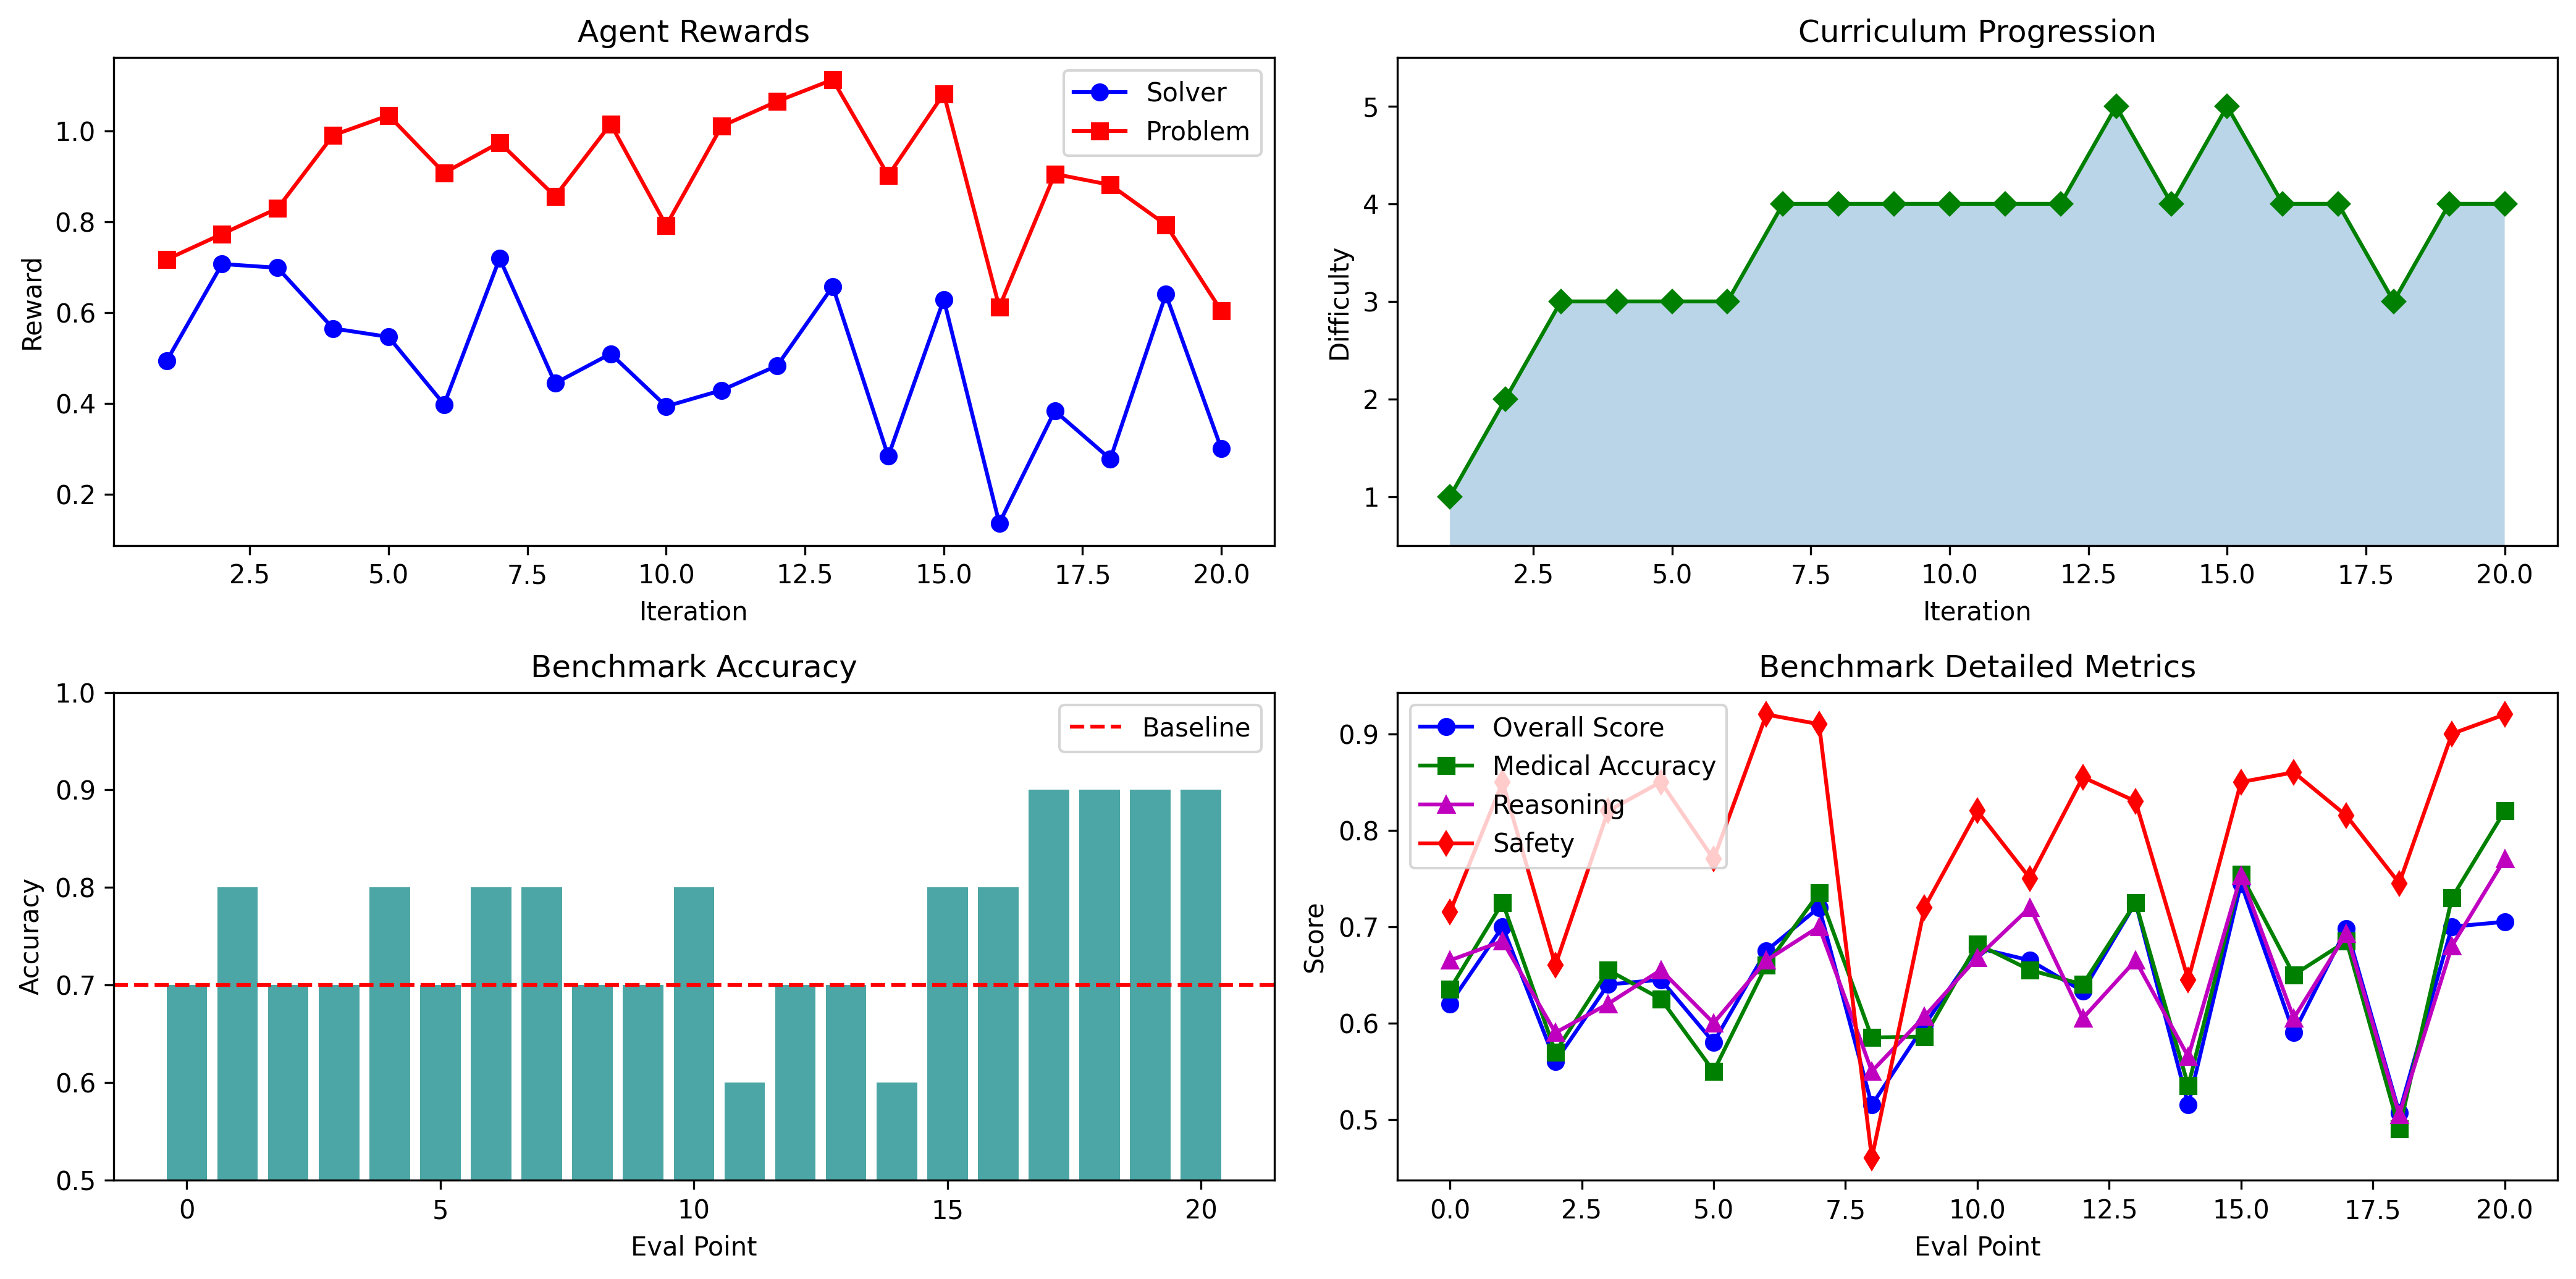


Results Summary:
  Baseline accuracy: 70.0%
  Final accuracy: 90.0%
  Final score: 70.5%
  Final medical accuracy: 82.0%
  Final reasoning: 77.0%
  Final safety: 92.0%


In [3]:
import json
import matplotlib.pyplot as plt

metrics = json.load(open("data/agent_training_metrics.json", "r"))

fig, axes = plt.subplots(2, 2, figsize=(14, 7), dpi=300)

# Rewards
axes[0, 0].plot(metrics["iterations"], metrics["solver_rewards"], 'b-o', label='Solver')
axes[0, 0].plot(metrics["iterations"], metrics["problem_rewards"], 'r-s', label='Problem')
axes[0, 0].set_xlabel('Iteration'); axes[0, 0].set_ylabel('Reward')
axes[0, 0].legend(); axes[0, 0].set_title('Agent Rewards')

# Difficulty
axes[0, 1].plot(metrics["iterations"], metrics["difficulty"], 'g-D')
axes[0, 1].fill_between(metrics["iterations"], metrics["difficulty"], alpha=0.3)
axes[0, 1].set_xlabel('Iteration'); axes[0, 1].set_ylabel('Difficulty')
axes[0, 1].set_ylim(0.5, 5.5); axes[0, 1].set_title('Curriculum Progression')

# Benchmark Accuracy
baseline_acc = metrics["benchmark_acc"][0]
axes[1, 0].bar(range(len(metrics["benchmark_acc"])), metrics["benchmark_acc"], color='teal', alpha=0.7)
axes[1, 0].axhline(baseline_acc, color='red', linestyle='--', label='Baseline')
axes[1, 0].set_xlabel('Eval Point'); axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].legend(); axes[1, 0].set_ylim(0.5, 1); axes[1, 0].set_title('Benchmark Accuracy')

# Benchmark Detailed Scores
x = range(len(metrics["benchmark_score"]))
axes[1, 1].plot(x, metrics["benchmark_score"], 'b-o', label='Overall Score')
axes[1, 1].plot(x, metrics["benchmark_medical_accuracy"], 'g-s', label='Medical Accuracy')
axes[1, 1].plot(x, metrics["benchmark_reasoning_quality"], 'm-^', label='Reasoning')
axes[1, 1].plot(x, metrics["benchmark_safety"], 'r-d', label='Safety')
axes[1, 1].set_xlabel('Eval Point'); axes[1, 1].set_ylabel('Score')
axes[1, 1].legend(); axes[1, 1].set_title('Benchmark Detailed Metrics')

plt.tight_layout(); plt.show()

# Summary
print(f"\nResults Summary:")
print(f"  Baseline accuracy: {baseline_acc:.1%}")
print(f"  Final accuracy: {metrics['benchmark_acc'][-1]:.1%}")
print(f"  Final score: {metrics['benchmark_score'][-1]:.1%}")
print(f"  Final medical accuracy: {metrics['benchmark_medical_accuracy'][-1]:.1%}")
print(f"  Final reasoning: {metrics['benchmark_reasoning_quality'][-1]:.1%}")
print(f"  Final safety: {metrics['benchmark_safety'][-1]:.1%}")

## 📊 Understanding the Results

Let's break down what these plots tell us about our co-evolution training run.

### Agent Rewards (Top Left)

This plot shows the learning dynamics between our two agents:

- **Solver reward (blue):** Measures how well the Solver handles generated problems. Values range from 0-1, with fluctuations between 0.3-0.7 being healthy. The dips you see (especially around iteration 15-17) occur when difficulty increases challenge the Solver.

- **Problem reward (red):** Measures whether the Problem Creator generates appropriately challenging cases. Values around **0.7-1.1 indicate the "sweet spot"** — problems that are hard enough to challenge the Solver but not impossible. Notice how this stays relatively stable throughout training.

**Key insight:** When solver reward drops significantly, it signals the Problem Creator is successfully generating challenging content. The system then self-corrects via curriculum adjustment.

### Curriculum Progression (Top Right)

This plot reveals the adaptive difficulty system in action:

| Phase | Iterations | What Happened |
|-------|------------|---------------|
| **Rapid early progress** | 1-7 | Solver quickly mastered easy problems, difficulty climbed from 1→4 |
| **Peak challenge** | 13-16 | Reached maximum difficulty (5) with expert-level cases |
| **Self-correction** | 17-18 | Solver struggled (reward < 0.3), system automatically reduced difficulty |
| **Stabilization** | 19-20 | Settled at difficulty 4, solver recovered |

**This automatic adjustment is crucial** — it prevents the training from collapsing when problems become too hard, while still pushing the Solver to improve.

### Benchmark Accuracy (Bottom Left)

The benchmark uses a **fixed set of 10 medical cases** not seen during training. This tells us whether learning generalizes:

- **Baseline (red dashed line):** 70% accuracy before any training
- **During training:** Fluctuates between 60-90% as the model adapts to different difficulty levels
- **Final performance:** 80-90%, **consistently above baseline**

**Why does accuracy dip sometimes?** When training intensively on complex cases (difficulty 4-5), the model temporarily specializes. The key metric is that it **recovers and exceeds baseline** — showing genuine learning, not just overfitting.

### Benchmark Detailed Metrics (Bottom Right)

This breaks down the Judge's evaluation across four dimensions:

| Metric | What It Measures | Trend |
|--------|------------------|-------|
| **Safety (red)** | Is medical advice safe and appropriate? | 📈 Strong improvement (0.65 → 0.90) |
| **Overall Score (blue)** | Combined quality assessment | 📈 Improved (0.65 → 0.70) |
| **Medical Accuracy (green)** | Correctness of diagnosis | 📈 Improved |
| **Reasoning (purple)** | Quality of clinical logic | 📈 Improved |

**The safety improvement is particularly important** for medical applications — the Solver learned not just to be accurate, but to be appropriately cautious.

### What Success Looks Like

Our training achieved several key objectives:

| Goal | Evidence | ✓ |
|------|----------|---|
| **Curriculum learning works** | Difficulty progressed 1→5, then self-corrected | ✓ |
| **No catastrophic forgetting** | Benchmark stayed above baseline | ✓ |
| **Co-evolution dynamics** | Problem Creator maintained sweet-spot rewards | ✓ |
| **Safety-aware learning** | Safety scores improved significantly | ✓ |
| **Generalization** | Fixed benchmark improved despite training on generated data | ✓ |

### Interpreting Variance

You'll notice considerable iteration-to-iteration variance. This is **normal and expected** because:

1. **Small batch sizes (8 problems)** — individual hard/easy cases have outsized impact
2. **Stochastic generation** — different problems each iteration
3. **LLM judge variance** — even with relative scoring, some noise remains
4. **RL exploration** — the model tries different strategies

The important pattern is the **overall trend**, not individual data points. Smooth, monotonic improvement is actually rare in RL — what matters is that the system recovers from dips and maintains generalization.

## 🎉 Conclusion

Congratulations! You've built a complete **Agentic RL** system where two AI agents improve each other through adversarial co-training.


### 🏗️ What We Built

| Component | Purpose | Key Insight |
|-----------|---------|-------------|
| 🔀 **Multi-Adapter LoRA** | Train 2 agents on 1 model | Shared knowledge, independent skills |
| ⚡ **Batched Generation** | 3-4x speedup | Maximize GPU utilization |
| ⚖️ **LLM-as-Judge** | Structured rewards | pydantic-ai for reliable evaluation |
| 📈 **GRPO** | Sample-efficient RL | 4 generations per prompt suffices |
| 📊 **Curriculum Learning** | Adaptive difficulty | Keeps training in the "zone of proximal development" |
| 🎭 **Adversarial Co-Training** | Self-improving system | Problems and solutions evolve together |

### 💡 Key Takeaways

1. **Curriculum matters** — Starting easy and increasing difficulty leads to stable training
2. **Sweet spot rewards** — Problem Creator learns to create challenging *but solvable* problems
3. **Safety is critical** — Heavy penalties keep medical advice grounded and safe
4. **Tool use enhances RL** — Web search provides real-world grounding during training
5. **Multi-adapter is efficient** — One base model, multiple specialized agents

### 🚀 Extensions to Explore

| Extension | Description |
|-----------|-------------|
| **Multi-Judge Ensemble** | Use multiple LLMs for more robust evaluation |
| **Online Learning** | Update agents in real-time as users interact |
| **Domain Transfer** | Apply to legal, financial, or scientific reasoning |
| **Constitutional AI** | Add explicit safety constraints to reward function |
| **Debate Protocol** | Have agents argue for/against diagnoses |


### 📚 References

- [GRPO Paper](https://arxiv.org/abs/2402.03300) — DeepSeekMath: Pushing the Limits
- [TRL Documentation](https://huggingface.co/docs/trl) — Transformer Reinforcement Learning
- [Pydantic AI](https://ai.pydantic.dev) — Type-safe AI agents
- [LoRA Paper](https://arxiv.org/abs/2106.09685) — Low-Rank Adaptation

🎮 **You've completed the bonus chapter!** You now have the tools to build self-improving AI systems that learn through competition and collaboration.